##  Probability Mass Functions

In [240]:
import sys
sys.path.append('../nb')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


| Term | Definition |
|------|-----------|
| normalized | A set of probabilities are normalized if they add up to 1. |
| probability mass function (PMF) | A function that represents a distribution by mapping each quantity to its probability. |


In this chapter we’ll introduce another way to describe a distribution, a probability mass function (PMF)

We’ll use Pmf objects to compute the mean and variance of a distribution, and the skewness, which indicates whether it is skewed to the left or right.

#### 3.1. PMFs

A Pmf object is like a FreqTab that contains probabilities instead of frequencies. So one way to make a Pmf is to start with a FreqTab.

In [241]:
from empiricaldist import FreqTab

ftab = FreqTab.from_seq([1, 2, 2, 3, 5])
ftab

,freqs
1,1
2,2
3,1
5,1


In [242]:
n = ftab.sum()
n

np.int64(5)

In [243]:
pmf = ftab / n
pmf

,probs
1,0.2
2,0.4
3,0.2
5,0.2


This result indicates that 20% of the values in the sequence are 1, 40% are 2, and so on.

The probability we choose the value 1 is 0.2, the probability we choose the value 2 is 0.4

Because we divided through by n, the sum of the probabilities is 1, which means that this distribution is normalized.

A normalized FreqTab object represents a probability mass function (PMF), so-called because probabilities associated with discrete values are also called “probability masses”.

The empiricaldist library provides a Pmf object that represents a probability mass function, so instead of creating a FreqTab object and then normalizing it, we can create a Pmf object directly.

In [244]:
from empiricaldist import Pmf

pmf = Pmf.from_seq([1, 2, 2, 3, 5])
pmf

,probs
1,0.2
2,0.4
3,0.2
5,0.2


In [245]:
pmf[2]

np.float64(0.4)

In [246]:
pmf[2] = 0.2
pmf(2)

np.float64(0.2)

You can modify an existing Pmf by incrementing the probability associated with a value:

In [247]:
pmf[2] += 0.3
pmf[2]

np.float64(0.5)

In [248]:
pmf[2] *= 0.5
pmf[2]

np.float64(0.25)

If you modify a Pmf, the result may not be normalized – that is, the probabilities may no longer add up to 1.

In [249]:
pmf.sum()

np.float64(0.8500000000000001)

The normalize method renormalizes the Pmf

In [250]:
pmf.normalize()

np.float64(0.8500000000000001)

In [251]:
pmf.copy()

,probs
1,0.235294
2,0.294118
3,0.235294
5,0.235294


### 3.2. Summarizing a PMF

In [252]:
seq = [1, 2, 2, 3, 5]

n = len(seq)
mean = np.sum(seq) / n
mean

np.float64(2.6)

In [253]:
pmf = Pmf.from_seq(seq)

In [254]:
mean = np.sum(pmf.ps * pmf.qs)
mean

np.float64(2.6)

In [255]:
pmf.mean()

np.float64(2.6)

Given a Pmf, we can compute the variance by computing the deviation of each quantity from the mean.

In [256]:
deviations = pmf.qs - mean

In [257]:
var = np.sum(pmf.ps * deviations**2)
var

np.float64(1.84)

In [258]:
pmf.var()

np.float64(1.84)

Standard deviation from the varience:

In [259]:
np.sqrt(var)

np.float64(1.3564659966250536)

In [260]:
pmf.std()

np.float64(1.3564659966250536)

In [261]:
pmf.mode()

np.int64(2)

### 3.3. The Class Size Paradox

In [262]:
ranges = pd.interval_range(start=5, end=50, freq=5, closed="left")
ranges.name = "class size"

data = pd.DataFrame(index=ranges)
data["count"] = [8, 8, 14, 4, 6, 12, 8, 3, 2]
data

,count
class size,
"[5, 10)",8
"[10, 15)",8
"[15, 20)",14
"[20, 25)",4
"[25, 30)",6
"[30, 35)",12
"[35, 40)",8
"[40, 45)",3
"[45, 50)",2


In [263]:
sizes = ranges.left + 2
sizes

Index([7, 12, 17, 22, 27, 32, 37, 42, 47], dtype='int64')

In [264]:
counts = data["count"]
actual_pmf = Pmf(counts, sizes, name="actual")
actual_pmf.normalize()

np.int64(65)

In [265]:
actual_pmf.mean()

np.float64(23.692307692307693)

In [266]:
def bias(pmf, name):
    # multiply each probability by class size
    ps = pmf.ps * pmf.qs

    # make a new Pmf and normalize it
    new_pmf = Pmf(ps, pmf.qs, name=name)
    new_pmf.normalize()
    return new_pmf

In [267]:
observed_pmf = bias(actual_pmf, name="observed")

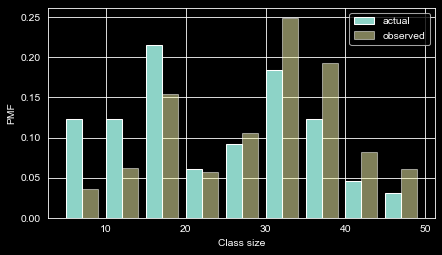

In [268]:
from thinkstats import two_bar_plots, decorate

two_bar_plots(actual_pmf, observed_pmf, width=2)
decorate(xlabel="Class size", ylabel="PMF")

In [269]:
observed_pmf.mean()

np.float64(29.123376623376622)

In [270]:
def unbias(pmf, name):
    # divide each probability by class size
    ps = pmf.ps / pmf.qs

    new_pmf = Pmf(ps, pmf.qs, name=name)
    new_pmf.normalize()
    return new_pmf

In [271]:
debiased_pmf = unbias(observed_pmf, "debiased")
debiased_pmf.mean()

np.float64(23.692307692307693)

### 3.4. NSFG Data

In [272]:
try:
    import statadict
except ImportError:
    %pip install statadict

In [273]:
import os
os.chdir('../data')

from nsfg import get_nsfg_groups

live, firsts, others = get_nsfg_groups()

os.chdir('../my-work')


C:\Users\xannx\PycharmProjects\ThinkStats\my-work\../nb\nsfg.py:220: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["totalwgt_lb"] = df.birthwgt_lb + df.birthwgt_oz / 16.0


In [274]:
first_pmf = Pmf.from_seq(firsts["prglngth"], name="firsts")
other_pmf = Pmf.from_seq(others["prglngth"], name="others")

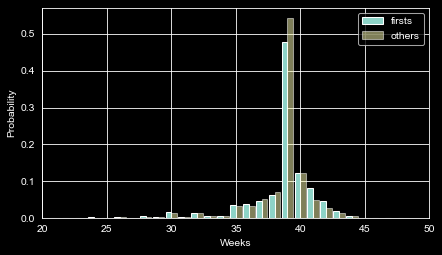

In [275]:
two_bar_plots(first_pmf, other_pmf)
decorate(xlabel="Weeks", ylabel="Probability", xlim=[20, 50])

### 3.5. Other Visualizations

In [276]:
weeks = range(35, 46)
first_pmf(weeks)

array([0.03602991, 0.03897575, 0.04713347, 0.06163608, 0.4790392 ,
       0.12145932, 0.08157716, 0.04645366, 0.01971448, 0.00521187,
       0.00135962])

In [277]:
other_pmf(weeks)

array([0.03210137, 0.03146779, 0.05216473, 0.07074974, 0.54466737,
       0.12249208, 0.04794087, 0.02597677, 0.01288279, 0.00485744,
       0.00084477])

In [278]:
diffs = first_pmf(weeks) - other_pmf(weeks)
diffs

array([ 0.00392854,  0.00750796, -0.00503126, -0.00911366, -0.06562817,
       -0.00103276,  0.03363629,  0.02047689,  0.00683169,  0.00035443,
        0.00051485])

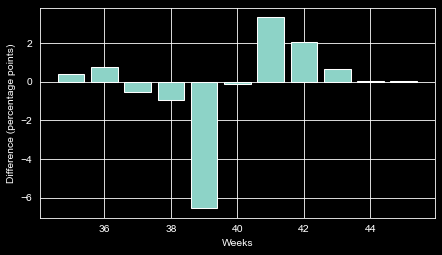

In [279]:
plt.bar(weeks, diffs * 100)
decorate(xlabel="Weeks", ylabel="Difference (percentage points)")

### 3.7. Exercises

In [280]:
from nsfg import read_fem_resp

os.chdir('../data')
resp = read_fem_resp()
os.chdir('../my-work')
resp.shape

C:\Users\xannx\PycharmProjects\ThinkStats\my-work\../nb\nsfg.py:191: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  resp["agemarry"] = (resp.cmmarrhx - resp.cmbirth) / 12.0
C:\Users\xannx\PycharmProjects\ThinkStats\my-work\../nb\nsfg.py:192: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  resp["age"] = (resp.cmintvw - resp.cmbirth) / 12.0
C:\Users\xannx\PycharmProjects\ThinkStats\my-work\../nb\nsfg.py:195: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has

(7643, 3092)

### 3.7.1. Exercise 3.1,
Select the column numbabes, which records the “number of babies born alive” to each respondent. Make a FreqTab object and display the frequencies of the values in this column. Check that they are consistent with the frequencies in the code book. Are there any special values that should be replaced with NaN?

Then make a Pmf object and plot it as a bar graph. Is the distribution symmetric, skewed to the left, or skewed to the right?

In [281]:
ftab = resp['numbabes']
FreqTab.from_seq(ftab)

,freqs
numbabes,
0,3229
1,1519
2,1603
3,828
4,309
5,95
6,29
7,15
8,8


In [282]:
# Replace 97 with NaN (special/invalid value)
resp['numbabes'] = resp['numbabes'].replace(97, np.nan)
FreqTab.from_seq(resp['numbabes'].dropna())


,freqs
numbabes,
0.0,3229
1.0,1519
2.0,1603
3.0,828
4.0,309
5.0,95
6.0,29
7.0,15
8.0,8


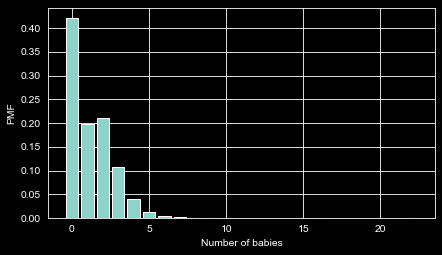

In [283]:
ftab = FreqTab.from_seq(resp['numbabes'].dropna())
pmf = ftab / ftab.sum()
pmf.bar()
decorate(xlabel="Number of babies", ylabel="PMF")

### 3.7.2. Exercise 3.2

A positive value indicates that a distribution is skewed to the right, and a negative value indicates that it is skewed to the left.

If you are given a Pmf, rather than a sequence of values, you can compute skewness like this:

Compute the deviation of each quantity in the Pmf from the mean.

Cube the deviations, multiply by the probabilities in the Pmf, and add up the products.

Divide the sum by the standard deviation cubed.

Write a function called pmf_skewness that takes a Pmf object and returns its skewness.

Use your function and the Pmf of numbabes to compute skewness, and confirm you get the same result we computed above.

In [284]:
deviations = pmf.qs - pmf.mean()
skewness = np.sum(pmf.ps * (deviations**3))
pmf_skewness = skewness / (pmf.std()**3)
pmf_skewness


np.float64(1.7018914266755958)

### 3.7.3. Exercise 3.3

From resp, select numkdhh, which records the number of children under 18 in each respondent’s household. Make a Pmf of the values in this column.

Use the bias function to compute the distribution we would see if we surveyed the children and asked them how many children under 18 (including themselves) are in their household.

Plot the actual and biased distributions, and compute their means.

(np.float64(1.024205155043831), np.float64(2.403679100664282))

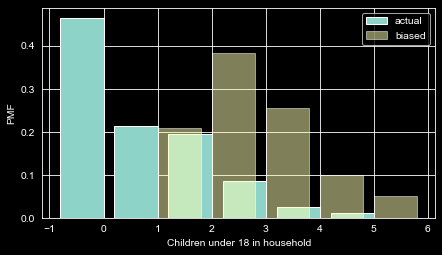

In [286]:
# Make a Pmf from numkdhh (drop missing or special codes if present)
numkdhh = resp['numkdhh'].dropna()
pmf = Pmf.from_seq(numkdhh, name="actual")

biased_pmf = bias(pmf, name="biased")

two_bar_plots(pmf, biased_pmf, width=0.8)
decorate(xlabel="Children under 18 in household", ylabel="PMF")

pmf.mean(), biased_pmf.mean()
